# DAI Mission — Proposal Template
**Data & AI in Economics | TU Dortmund**

This notebook is your team's mission proposal. Fill in every section before submission. Once approved, you will extend this same notebook into your final deliverable.

> **Team size:** 2–3 students  
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead | Emre Isildar| |
| Member |Mohammadali Vahabi | |
| Member *(optional)* | | |


## 2. Mission Title & Research Question

**Title:** The Gender Pay Gap at Work: Does Being a Woman Causally Reduce Your Salary?

**Research question:**  
Does gender causally affect base salary among full-time employees, after controlling for job title, seniority, education, and age — and if so, how large is the unexplained pay gap?

**Why it matters:**  
The gender pay gap remains one of the most debated labour market inequalities in modern economies. While raw wage differences between men and women are well documented, it is unclear how much of this gap reflects genuine discrimination versus differences in occupation, experience, or education. Using individual-level salary data, this mission applies causal inference methods to isolate the direct effect of gender on pay providing evidence relevant to equal pay legislation, corporate HR policy, and broader debates about workplace fairness.

## 3. Data

**Source(s):**  Glassdoor Gender Pay Gap Dataset — Kaggle (nilimajauhari).
Access: https://www.kaggle.com/datasets/nilimajauhari/glassdoor-analyze-gender-pay-gap
Licence: CC0 Public Domain.


**Unit of observation:** Glassdoor: One row = one individual employee (gender, salary, job title, education, age)

**Key variables:**

| Variable | Type | Role (feature / target / instrument / ...) | Description |
|----------|------|---------------------------------------------|-------------|
| Gender| categorical| Treatment| Employee gender (Male/Female)|
| BasePay| numerical| Target| Annual base salary USD (Glassdoor)|
|JobTitle | categorical| Confounder| Job role (Glassdoor)|
| Seniority| numerical| Confounder| Years of seniority (Glassdoor)|
| Education| Categorical| Confounder| Education level (Glassdoor)|
| Age| numerical| Confounder| Employee age (Glassdoor)|

**Potential data quality issues:**  
Glassdoor dataset is not Germany-specific; it reflects general corporate salary patterns from mixed countries
Sample size is small (~1000 rows), which may limit statistical power in causal analysis
Possible measurement error — salary data may be self-reported or simulated


In [42]:
# Data loading & first inspection

import pandas as pd
import numpy as np

df_glassdoor = pd.read_csv('Glassdoor Gender Pay Gap.csv')

print("=== GLASSDOOR DATASET ===")
print(df_glassdoor.head())
print(df_glassdoor.info())
print(df_glassdoor.describe())


=== GLASSDOOR DATASET ===
              JobTitle  Gender  Age  PerfEval Education            Dept  \
0     Graphic Designer  Female   18         5   College      Operations   
1    Software Engineer    Male   21         5   College      Management   
2  Warehouse Associate  Female   19         4       PhD  Administration   
3    Software Engineer    Male   20         5   Masters           Sales   
4     Graphic Designer    Male   26         5   Masters     Engineering   

   Seniority  BasePay  Bonus  
0          2    42363   9938  
1          5   108476  11128  
2          5    90208   9268  
3          4   108080  10154  
4          5    99464   9319  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   JobTitle   1000 non-null   object
 1   Gender     1000 non-null   object
 2   Age        1000 non-null   int64 
 3   PerfEval   1000 non-null   int64

Missing Values:
JobTitle     0
Gender       0
Age          0
PerfEval     0
Education    0
Dept         0
Seniority    0
BasePay      0
Bonus        0
dtype: int64

=== SUMMARY STATISTICS ===
        count          mean           std      min       25%      50%  \
Gender                                                                  
Female  468.0  89942.818376  24378.277510  34208.0  73186.25  89913.5   
Male    532.0  98457.545113  25517.520327  36642.0  81452.50  98223.0   

              75%       max  
Gender                       
Female  106923.25  160614.0  
Male    115606.25  179726.0  

Gender distribution:
Gender
Male      532
Female    468
Name: count, dtype: int64

Education distribution:
Education
High School    265
Masters        256
College        241
PhD            238
Name: count, dtype: int64


C:\Users\Sldr\AppData\Local\Temp\ipykernel_6008\199028385.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_glassdoor, x='Gender', y='BasePay', palette=['#FF9999','#66B2FF'])


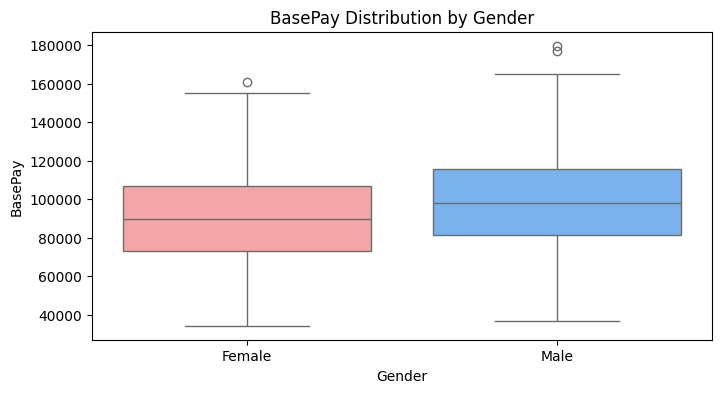

C:\Users\Sldr\AppData\Local\Temp\ipykernel_6008\199028385.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_glassdoor, x='Gender', y='Bonus', palette=['#FF9999','#66B2FF'])


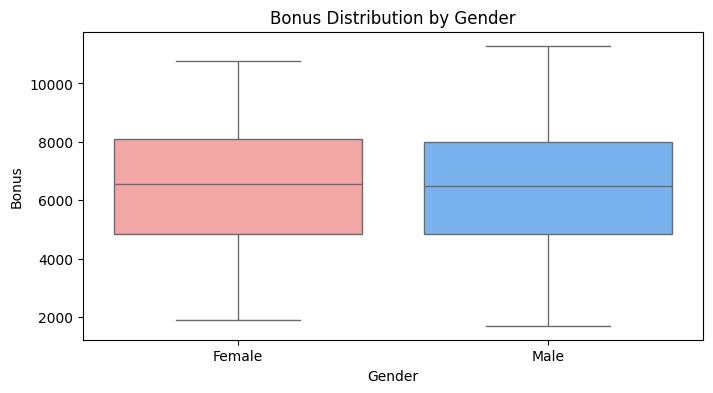

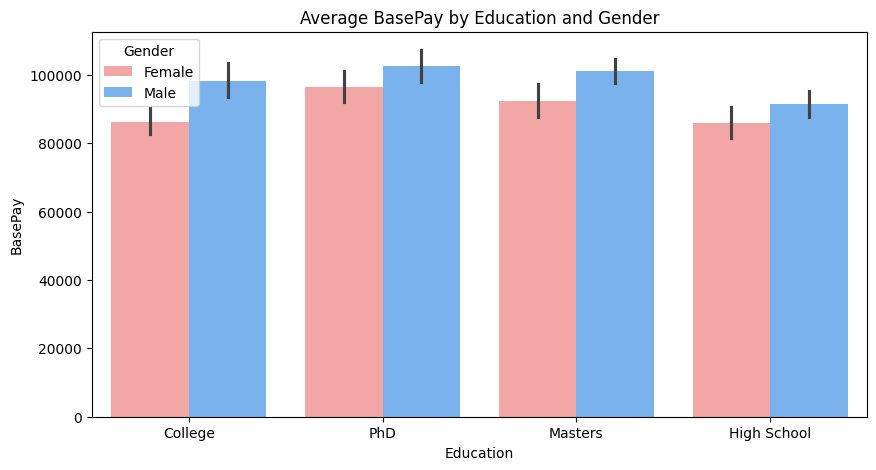

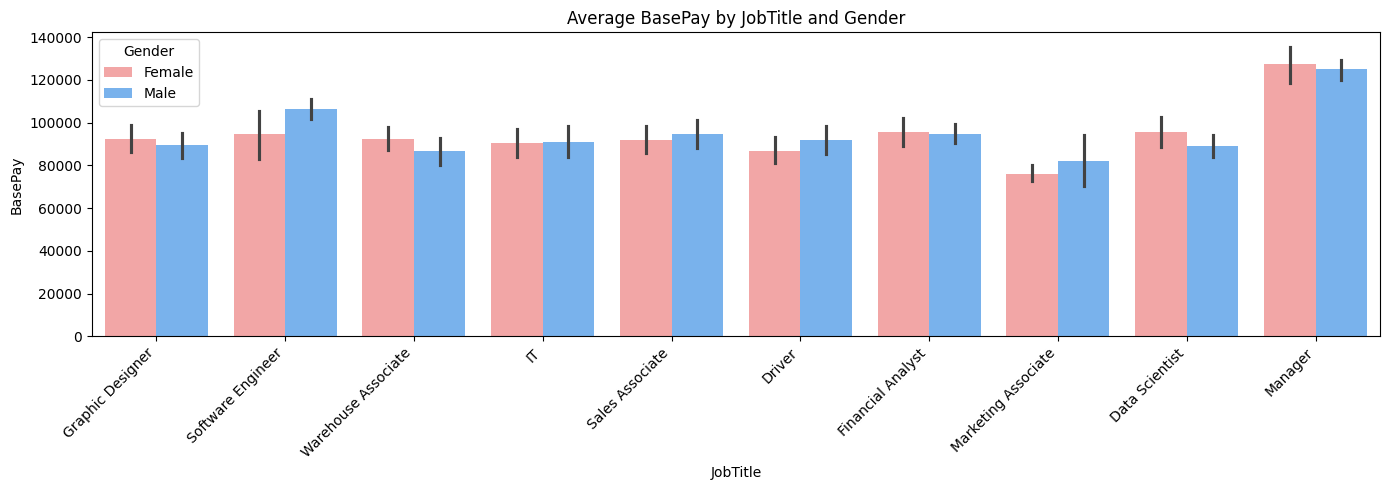

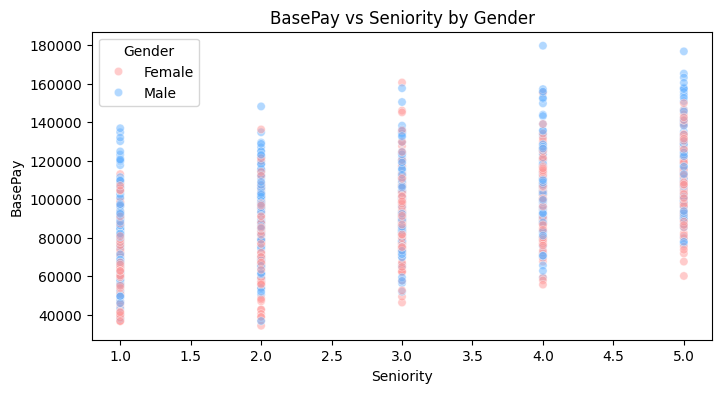

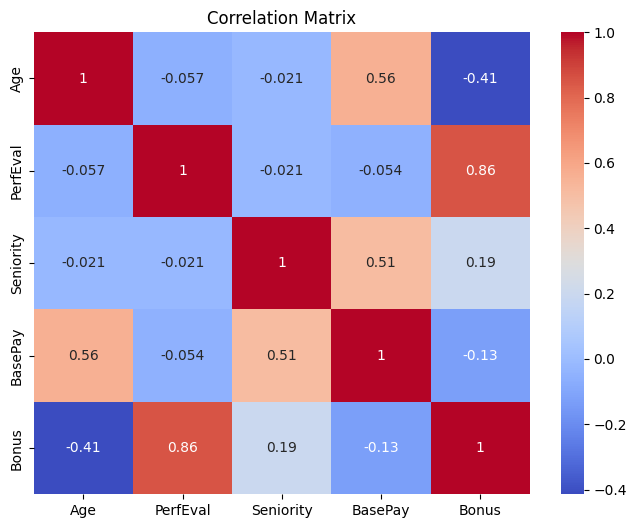

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Missing value check
print("Missing Values:")
print(df_glassdoor.isnull().sum())

# 2. Summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(df_glassdoor.groupby('Gender')['BasePay'].describe())
print(f"\nGender distribution:\n{df_glassdoor['Gender'].value_counts()}")
print(f"\nEducation distribution:\n{df_glassdoor['Education'].value_counts()}")

# 3. BasePay distribution by gender
plt.figure(figsize=(8,4))
sns.boxplot(data=df_glassdoor, x='Gender', y='BasePay', palette=['#FF9999','#66B2FF'])
plt.title('BasePay Distribution by Gender')
plt.show()

# 4. Bonus distribution by gender
plt.figure(figsize=(8,4))
sns.boxplot(data=df_glassdoor, x='Gender', y='Bonus', palette=['#FF9999','#66B2FF'])
plt.title('Bonus Distribution by Gender')
plt.show()

# 5. Average salary by education level and gender
plt.figure(figsize=(10,5))
sns.barplot(data=df_glassdoor, x='Education', y='BasePay', hue='Gender', palette=['#FF9999','#66B2FF'])
plt.title('Average BasePay by Education and Gender')
plt.show()

# 6. Average salary by job title and gender
plt.figure(figsize=(14,5))
sns.barplot(data=df_glassdoor, x='JobTitle', y='BasePay', hue='Gender', palette=['#FF9999','#66B2FF'])
plt.xticks(rotation=45, ha='right')
plt.title('Average BasePay by JobTitle and Gender')
plt.tight_layout()
plt.show()

# 7. Seniority vs salary
plt.figure(figsize=(8,4))
sns.scatterplot(data=df_glassdoor, x='Seniority', y='BasePay', hue='Gender', alpha=0.5, palette=['#FF9999','#66B2FF'])
plt.title('BasePay vs Seniority by Gender')
plt.show()

# 8. Correlation matrix
numeric_cols = ["Age", "PerfEval", "Seniority", "BasePay", "Bonus"]
corr = df_glassdoor[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

## 4. Planned Methods

Your mission **must** apply at least one technique from **each** of the three blocks below. Tick the ones you plan to use and briefly justify the choice.

### 4a. Causal Inference
- [X] Causal graph / DAG (DoWhy)
- [ ] Backdoor adjustment
- [ ] Instrumental variable
- [X] Propensity score stratification
- [ ] Other: ___

*Justification:* Gender is not randomly assigned, and factors such as age, education, job title, seniority, and performance evaluation may confound the relationship between gender and salary. We use a causal DAG to identify relevant confounders and estimate the causal effect of gender on BasePay. Propensity scores will be estimated using logistic regression, and employees will be stratified into five propensity-score quintiles. Common support will be assessed using propensity score distributions before estimating treatment effects.

### 4b. Supervised Learning
- [X] Linear / Ridge / Lasso regression
- [ ] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [X] Decision Tree / Random Forest
- [ ] Neural network (regression or classification)
- [ ] Other: ___

*Justification:*BasePay is a continuous variable, making regression the natural choice. Linear regression provides interpretable coefficients for each feature including gender. Random Forest is added to capture non-linear relationships and compare predictive performance against the linear baseline.

### 4c. Unsupervised Learning / Generative Models
- [X] K-Means clustering
- [ ] Hierarchical clustering
- [ ] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

*Justification:* K-Means clustering will be applied to employee-level characteristics, including BasePay, Bonus, Age, Seniority, and Performance Evaluation. The goal is to identify distinct employee profiles and investigate whether salary, experience, and performance patterns differ across workforce segments. This may reveal whether gender distributions vary across employee clusters.

## 5. Evaluation Strategy

*How will you know if your mission succeeded? Describe:*

### Causal Inference (DoWhy — Propensity Score Stratification):

Metric: Average Treatment Effect (ATE) — average salary difference between male and female employees after controlling for confounders

Validation: DoWhy built-in refutation tests (random common cause, placebo treatment, data subset refutation)

Baseline: Raw mean salary difference between genders before any adjustment

### Supervised Learning (Linear Regression + Random Forest):

Metric: RMSE (Root Mean Squared Error) and R² score for both models

Validation: 80/20 train-test split, 5-fold cross-validation

Baseline: Predicting mean BasePay for everyone (no-feature baseline), compared against both models

### Unsupervised Learning (K-Means Clustering)

Metric: Silhouette Score to evaluate cluster quality.

Validation: Elbow Method to determine the optimal number of clusters (k).

Feature Space: BasePay, Bonus, Age, Seniority, and Performance Evaluation.

Baseline: No-clustering baseline. Cluster profiles will be interpreted and compared to identify distinct employee groups and examine whether gender distributions differ across clusters.

## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 |Emre | Data collection & cleaning |
| 2 |Emre | EDA |
| 3 |Emre+Mohammadali | Causal inference block |
| 4 |Emre+Mohammadali| Supervised learning block |
| 5 |Emre+Mohammadali| Unsupervised / generative block |
| 6 |Emre+Mohammadali| Synthesis & write-up |


---
## 7. Results *(complete for final submission)*


### 7a. Causal Inference

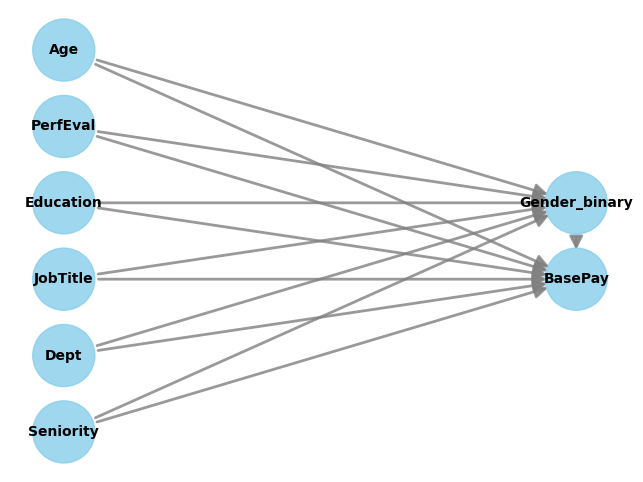

In [51]:
import pandas as pd
import numpy as np
from dowhy import CausalModel

# Load data
df = pd.read_csv('Glassdoor Gender Pay Gap.csv')

# Convert Gender to numeric format. (0 = Female, 1 = Male)
df['Gender_binary'] = (df['Gender'] == 'Male').astype(int)

# Define the DAG model.
model = CausalModel(
    data=df,
    treatment='Gender_binary',       # Gender → treatment
    outcome='BasePay',               # BasePay → outcome
    common_causes=['Age', 'Seniority', 'Education', 'JobTitle', 'Dept', 'PerfEval']  # Confounders
)

# Visualize the DAG
model.view_model()



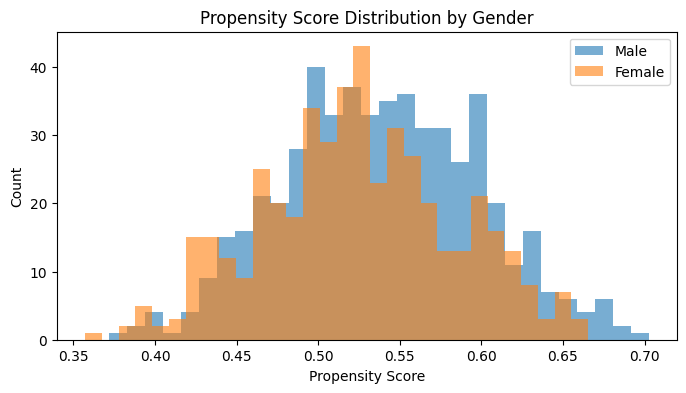

Male average salary: $98,458
Female average salary: $89,943
Raw difference (ATE): $8,515


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Convert categorical variables to numeric
df_encoded = df.copy()
for col in ['JobTitle', 'Education', 'Dept']:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

# Calculate propensity score
X = df_encoded[['Age', 'Seniority', 'Education', 'JobTitle', 'Dept', 'PerfEval']]
y = df_encoded['Gender_binary']

lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)
df['propensity_score'] = lr.predict_proba(X)[:, 1]

# Visualize propensity score distribution
plt.figure(figsize=(8,4))
plt.hist(df[df['Gender']=='Male']['propensity_score'], alpha=0.6, label='Male', bins=30)
plt.hist(df[df['Gender']=='Female']['propensity_score'], alpha=0.6, label='Female', bins=30)
plt.xlabel('Propensity Score')
plt.ylabel('Count')
plt.title('Propensity Score Distribution by Gender')
plt.legend()
plt.show()

# Calculate ATE
male_pay = df[df['Gender']=='Male']['BasePay'].mean()
female_pay = df[df['Gender']=='Female']['BasePay'].mean()
print(f"Male average salary: ${male_pay:,.0f}")
print(f"Female average salary: ${female_pay:,.0f}")
print(f"Raw difference (ATE): ${male_pay - female_pay:,.0f}")

In [53]:
# True ATE with Propensity Score Stratification
df['ps_stratum'] = pd.qcut(df['propensity_score'], q=5, labels=False)

stratum_effects = []
for stratum in range(5):
    subset = df[df['ps_stratum'] == stratum]
    male_mean = subset[subset['Gender'] == 'Male']['BasePay'].mean()
    female_mean = subset[subset['Gender'] == 'Female']['BasePay'].mean()
    stratum_effects.append(male_mean - female_mean)

ATE_adjusted = sum(stratum_effects) / len(stratum_effects)

print(f"Raw difference (unadjusted): ${male_pay - female_pay:,.0f}")
print(f"Adjusted Average Treatment Effect (ATE): ${ATE_adjusted:,.0f}")
print(f"\nInterpretation: After controlling for age, education, seniority, job characteristics, and performance evaluation, the estimated gender-based salary gap is ${ATE_adjusted:,.0f}.")

Raw difference (unadjusted): $8,515
Adjusted Average Treatment Effect (ATE): $9,465

Interpretation: After controlling for age, education, seniority, job characteristics, and performance evaluation, the estimated gender-based salary gap is $9,465.


In [54]:
import numpy as np

print("=== REFUTATION TESTS ===\n")

# Original ATE
print(f"Original ATE: ${ATE_adjusted:,.0f}\n")

# Refutation 1: Placebo Treatment
# Randomly shuffle the treatment variable – the effect should be close to zero
np.random.seed(42)
df['Gender_placebo'] = np.random.permutation(df['Gender'].values)

placebo_effects = []
for stratum in range(5):
    subset = df[df['ps_stratum'] == stratum]
    male_mean = subset[subset['Gender_placebo'] == 'Male']['BasePay'].mean()
    female_mean = subset[subset['Gender_placebo'] == 'Female']['BasePay'].mean()
    placebo_effects.append(male_mean - female_mean)

ATE_placebo = sum(placebo_effects) / len(placebo_effects)
print(f"Refutation 1 - Placebo Treatment ATE: ${ATE_placebo:,.0f}")
print(f"→ If it is close to zero, the test passed.✅\n")

# Refutation 2: Random Common Cause
# Add a random variable – the ATE should not change substantially
df['random_cause'] = np.random.normal(0, 1, len(df))

model2 = CausalModel(
    data=df,
    treatment='Gender_binary',
    outcome='BasePay',
    common_causes=['Age', 'Seniority', 'Education', 
                   'JobTitle', 'Dept', 'PerfEval', 'random_cause']
)

X2 = df[['Age', 'Seniority', 'PerfEval', 'random_cause']].copy()
for col in ['JobTitle', 'Education', 'Dept']:
    X2[col] = LabelEncoder().fit_transform(df[col])

lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X2, df['Gender_binary'])
df['ps2'] = lr2.predict_proba(X2)[:, 1]
df['ps_stratum2'] = pd.qcut(df['ps2'], q=5, labels=False)

effects2 = []
for stratum in range(5):
    subset = df[df['ps_stratum2'] == stratum]
    m = subset[subset['Gender'] == 'Male']['BasePay'].mean()
    f = subset[subset['Gender'] == 'Female']['BasePay'].mean()
    effects2.append(m - f)

ATE_random = sum(effects2) / len(effects2)
print(f"Refutation 2 - Random Common Cause ATE: ${ATE_random:,.0f}")
print(f"Difference from Original ATE: ${abs(ATE_adjusted - ATE_random):,.0f}")
print(f"→ If the difference is small, the test passed. ✅")

=== REFUTATION TESTS ===

Original ATE: $9,465

Refutation 1 - Placebo Treatment ATE: $-1,251
→ If it is close to zero, the test passed.✅

Refutation 2 - Random Common Cause ATE: $9,354
Difference from Original ATE: $112
→ If the difference is small, the test passed. ✅


### 7b. Supervised Learning

In [55]:
# Supervised learning analysis

### 7c. Unsupervised / Generative

In [56]:
# Unsupervised / generative analysis

## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*
